In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
fp = r'mactan_temps_daily.csv'

data = pd.read_csv(fp,
    na_values=["***"],
    usecols=["DATE", "TAVG"],
    parse_dates=["DATE"]
)


In [30]:
data["year"] = data["DATE"].dt.year
data["month"] = data["DATE"].dt.month
data["yrmo"] = data["DATE"].dt.strftime('%Y-%m')
data.head()

,DATE,TAVG,year,month,yrmo
0,1965-07-31,25.0,1965,7,1965-07
1,1965-08-01,27.5,1965,8,1965-08
2,1965-08-02,27.8,1965,8,1965-08
3,1965-08-03,28.2,1965,8,1965-08
4,1965-08-04,28.6,1965,8,1965-08


Text(1980, 27.6, 'Correlation coefficient: 0.20')

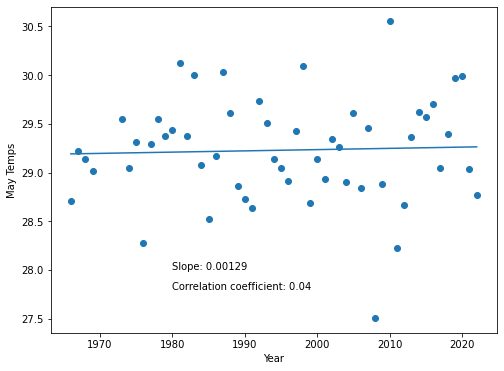

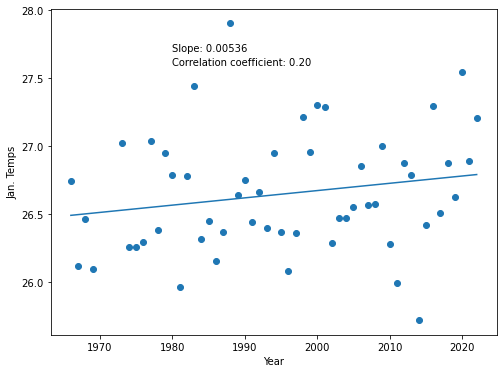

In [128]:

def linregress(xs, ys):
    # Calculate our slope and y-intercept
    delta = len(xs) * (xs**2).sum() - (xs.sum())**2
    a = (((xs**2).sum() * ys.sum()) - (xs.sum() * (xs * ys).sum())) / delta
    b = ((len(xs) * (xs * ys).sum()) - (xs.sum() * ys.sum())) / delta

    return a, b


def correl(xs, ys):
    import numpy as np
    # Initialize our summing variables
    topsum = 0
    bottomsumx = 0
    bottomsumy = 0

    # Calculate our top and bottom sums
    for i in range(len(xs)):
        topsum = topsum + (xs[i] - xs.mean()) * (ys[i] - ys.mean())
        bottomsumx = bottomsumx + (xs[i] - xs.mean())**2
        bottomsumy = bottomsumy + (ys[i] - ys.mean())**2

    # Calculate r
    r = topsum / np.sqrt(bottomsumx * bottomsumy)

    return r


# groupby year month first
grouped = data.groupby(["yrmo"])
len(grouped)

# take average per yr-month
dates = []
temps = []
sd = []
molydf = pd.DataFrame()

for key, group in grouped:
    #print(f"Year-Month: {key}")
    meanT = group["TAVG"].mean()
    stdT = group["TAVG"].std()
    #print(f"Average temperature: {meanT_yr} +/- {stdT_yr} (1 s.d.)")
    dates.append(key[0])
    temps.append(meanT)
    sd.append(stdT)

molydf['date'] = pd.to_datetime(dates)
#meanTdf['date'] = pd.to_datetime(meanTdf['date'])
molydf['temp'] = temps
molydf['std'] = sd
molydf['mo'] = molydf['date'].dt.strftime('%m')
molydf['yr'] = molydf['date'].dt.strftime('%Y')

#meanTdf.plot('date','temp')

# group by month
mo_grp = molydf.groupby(['mo'])

import copy
# save June as Summer df
junes = copy.deepcopy(molydf.loc[molydf['mo'] == "06"])
mays = molydf.loc[molydf['mo'] == "05"]
jans = molydf.loc[molydf['mo'] == "01"]

#ax = mays.plot(x='yr',y='temp', color='red')
#jans.plot(x='yr',y='temp', ax=ax, color='blue')

# save jans as winter df

mays
    
# Print out result
years = mays["yr"].values.astype(int)
temps = mays["temp"].values

a, b = linregress(years, temps)
r = correl(years, temps)

# Create figure and axes
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Plot data
ax.scatter(years, temps)
ax.plot([years.min(), years.max()], [a + b * years.min(), a + b * years.max()])
ax.set_xlabel('Year')
ax.set_ylabel('May Temps')
ax.text(1980, 28, f"Slope: {b:.5f}")
#plt.show()
ax.text(1980, 27.8, f"Correlation coefficient: {r:.2f}")



years = jans["yr"].values.astype(int)
temps = jans["temp"].values

a, b = linregress(years, temps)
r = correl(years, temps)

# Create figure and axes
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Plot data
ax.scatter(years, temps)
ax.plot([years.min(), years.max()], [a + b * years.min(), a + b * years.max()])
ax.set_xlabel('Year')
ax.set_ylabel('Jan. Temps')
ax.text(1980, 27.7, f"Slope: {b:.5f}")
#plt.show()
ax.text(1980, 27.6, f"Correlation coefficient: {r:.2f}")

In [53]:
dates = []
temps = []
sd = []
meanTdf = pd.DataFrame()

for key, group in grouped:
    #print(f"Year-Month: {key}")
    meanT = group["TAVG"].mean()
    stdT = group["TAVG"].std()
    #print(f"Average temperature: {meanT_yr} +/- {stdT_yr} (1 s.d.)")
    dates.append(key[0])
    temps.append(meanT)
    sd.append(stdT)

meanTdf['date'] = dates
#meanTdf['date'] = pd.to_datetime(meanTdf['date'])
meanTdf['temp'] = temps
meanTdf['std'] = sd
    
meanTdf.plot('date','temp')

,date,temp,std,mo
0,1965-07-01,25.000000,NaN,07
1,1965-08-01,27.990323,0.911173,08
2,1965-09-01,27.790000,0.654085,09
3,1965-10-01,27.835484,0.686318,10
4,1965-11-01,27.516667,0.697327,11
...,...,...,...,...
649,2022-08-01,28.038710,0.921114,08
650,2022-09-01,28.753333,0.986716,09
651,2022-10-01,28.029032,0.909650,10
652,2022-11-01,28.133333,0.958567,11
